In [1]:
import pandas as pd
df_all = pd.read_csv("GSE119009_DEG_U1_Vs_Control_Original.csv")
df_all.head()

,Ref ID,locus,Control,Treated,FPKM_Control,FPKM_U1,log2FC U1 Vs C,test_stat,p_value,q_value,Gene Symbol
0,NM_000016,chr1:75724346-75763678,NHHW161152,U1,6.42683,9.35583,0.542,6.621,0.000,0.000,ACADM
1,NM_000017,chr12:120725737-120740008,NHHW161152,U1,8.22129,9.11939,0.150,1.635,0.044,0.052,ACADS
2,NM_000018,chr17:7189890-7225267,NHHW161152,U1,248.72800,105.57200,-1.236,-34.901,0.000,0.000,ACADVL
3,NM_000019,chr11:108121530-108148164,NHHW161152,U1,22.71930,53.62050,1.239,29.579,0.000,0.000,ACAT1
4,NM_000020,chr12:51907417-51923361,NHHW161152,U1,11.51530,43.36210,1.913,39.739,0.000,0.000,ACVRL1


In [3]:
df_sig = df_all[df_all["p_value"] < 0.05]
df_sig = df_sig[abs(df_sig["log2FC U1 Vs C"]) > 1]

In [4]:
df_sig.shape

(4793, 11)

C:\Users\bim12\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


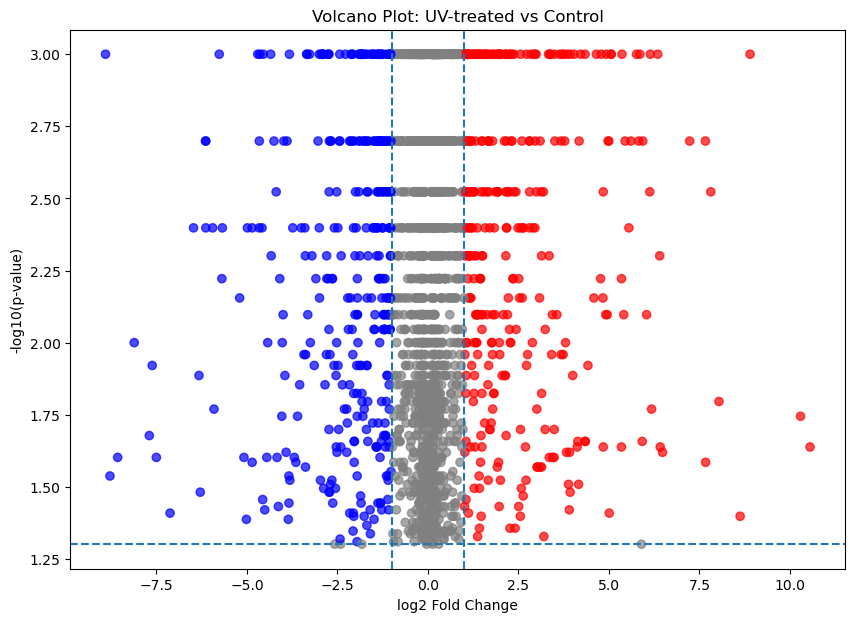

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 기준 설정
p_threshold = 0.05
fc_threshold = 1

# significance 계산
df_all["minus_log10_p"] = -np.log10(df_all["p_value"])

# 색상 분류
colors = []

for i in range(len(df_all)):
    
    log2fc = df_all.iloc[i]["log2FC U1 Vs C"]
    pval = df_all.iloc[i]["p_value"]
    
    if pval < p_threshold and log2fc > fc_threshold:
        colors.append("red")      # upregulated
    
    elif pval < p_threshold and log2fc < -fc_threshold:
        colors.append("blue")     # downregulated
    
    else:
        colors.append("gray")     # non-significant

# volcano plot 생성
plt.figure(figsize=(10, 7))

plt.scatter(
    df_all["log2FC U1 Vs C"],
    df_all["minus_log10_p"],
    c=colors,
    alpha=0.7
)

# threshold line 추가
plt.axvline(x=fc_threshold, linestyle="--")
plt.axvline(x=-fc_threshold, linestyle="--")
plt.axhline(y=-np.log10(p_threshold), linestyle="--")

# label
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot: UV-treated vs Control")

plt.show()


In [6]:
ecm_data = df_sig[df_sig["Gene Symbol"].str.contains("COL|MMP|FN|LAM", na=False)]
inflam_data = df_sig[df_sig["Gene Symbol"].str.contains("IL|CXCL|TNF|CCL", na=False)]

ecm_mean = ecm_data["log2FC U1 Vs C"].mean()
inflam_mean = inflam_data["log2FC U1 Vs C"].mean()

print("ECM:", ecm_mean)
print("Inflammation:", inflam_mean)

ECM: 0.15718840579710136
Inflammation: -1.4997536231884059


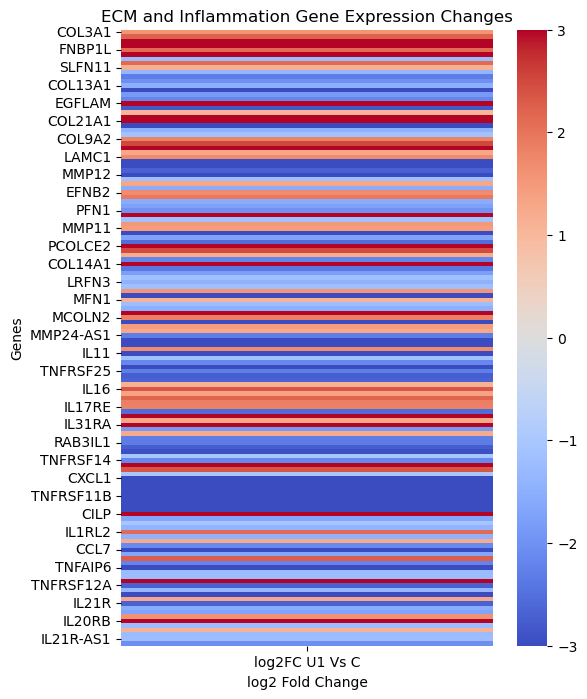

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# gene 선택 (이미 만든 것 활용)
selected_data = pd.concat([ecm_data, inflam_data])

# index를 gene symbol로 설정
selected_data = selected_data.set_index("Gene Symbol")

# heatmap 데이터
heatmap_values = selected_data[["log2FC U1 Vs C"]]

plt.figure(figsize=(6,8))
sns.heatmap(heatmap_values, cmap="coolwarm", center=0, vmin=-3, vmax=3)

plt.title("ECM and Inflammation Gene Expression Changes")
plt.xlabel("log2 Fold Change")
plt.ylabel("Genes")

plt.show()


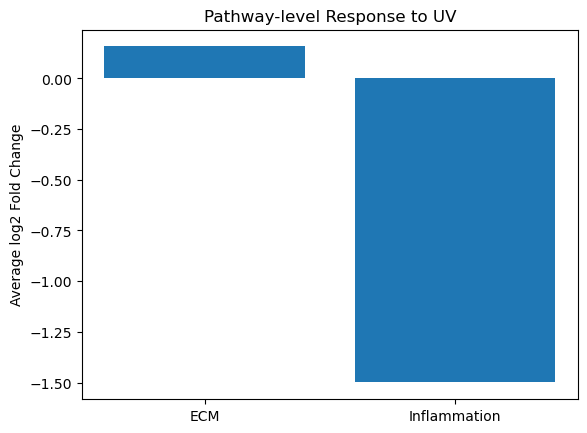

In [8]:
plt.figure()

plt.bar(["ECM", "Inflammation"], [ecm_mean, inflam_mean])

plt.ylabel("Average log2 Fold Change")
plt.title("Pathway-level Response to UV")

plt.show()

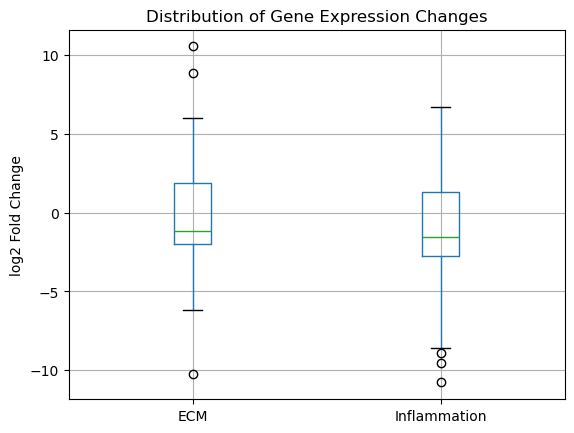

In [9]:
import pandas as pd

ecm_vals = ecm_data["log2FC U1 Vs C"]
inflam_vals = inflam_data["log2FC U1 Vs C"]

plot_df = pd.DataFrame({
    "ECM": ecm_vals,
    "Inflammation": inflam_vals
})

plot_df.boxplot()

plt.ylabel("log2 Fold Change")
plt.title("Distribution of Gene Expression Changes")

plt.show()


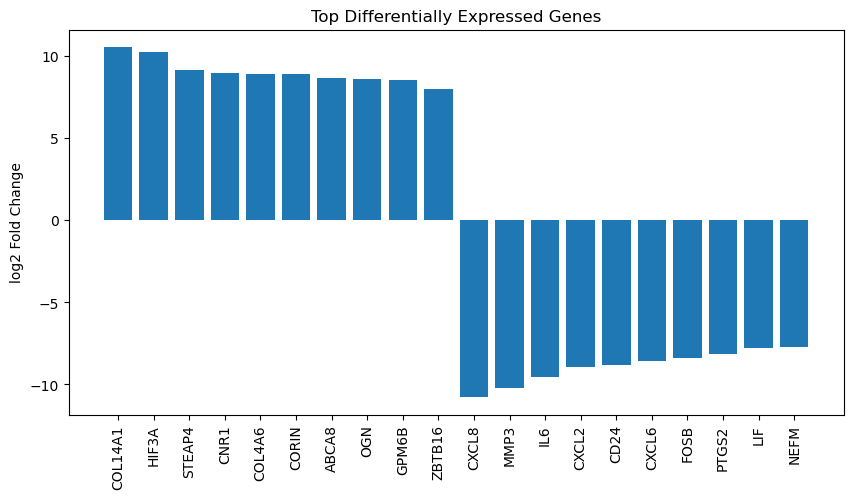

In [10]:
top_up = df_sig.sort_values("log2FC U1 Vs C", ascending=False).head(10)
top_down = df_sig.sort_values("log2FC U1 Vs C").head(10)

genes = list(top_up["Gene Symbol"]) + list(top_down["Gene Symbol"])
values = list(top_up["log2FC U1 Vs C"]) + list(top_down["log2FC U1 Vs C"])

plt.figure(figsize=(10,5))
plt.bar(genes, values)

plt.xticks(rotation=90)
plt.ylabel("log2 Fold Change")
plt.title("Top Differentially Expressed Genes")

plt.show()